In [ ]:
# install required packages (remove the extra leading single quotes)
!pip install pandas>=1.0.1
!pip install torch>=1.9.0
!pip install pymoo==0.6.0
!pip install scikit-learn>=0.22
!pip install gpytorch>=1.4.0
!pip install GPy>=1.9.9
!pip install catboost>=0.24.4
!pip install disjoint-set

In [ ]:
!pip install HEBO --no-deps

In [ ]:
# Import everything needed for HEBO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hebo.optimizers.hebo import HEBO
from hebo.optimizers.bo import BO
from hebo.design_space.design_space import DesignSpace

import warnings
warnings.filterwarnings("ignore")

# Example with a 2D synthetic function

Let's consider a simple example in 2-dimension so we can visualize everything.

### Objective Function

We define below an objective function `obj` that takes as inputs a dataframe object `pandas.DataFrame`, i.e. a table, with two columns named `"x0","x1"`.

In [12]:
a = 1.0
b = 5.1 / (4 * np.pi**2)
c = 5 / np.pi
d = 6.0
e = 10.0
f = 1 / (8 * np.pi)

def branin_hoo(x : pd.DataFrame) -> np.ndarray:
    """Calculates the Branin-Hoo function value."""
    x = x[['x0','x1']].values
    x0, x1 = x[:,0], x[:,1]
    term1 = a * (x1 - b * x0**2 + c * x0 - d)**2
    term2 = e * (1 - f) * np.cos(x0)
    term3 = e
    return np.array(term1 + term2 + term3).reshape(-1, 1)

### Design  Space

To be able to use `HEBO` and in general for using any numerical optimizer, we need to specify the design space, i.e. the space in which the inputs to the objective live in and a bounding box in which we will search for the optimal input $x^*=\arg\min f(x)$ that minimizes the objective $f(\cdot)$.

In [10]:
space = DesignSpace().parse([
    {'name' : 'x0', 'type' : 'num', 'lb' : -5, 'ub' : 10},
    {'name' : 'x1', 'type' : 'num', 'lb' : 0,  'ub' : 15}
])

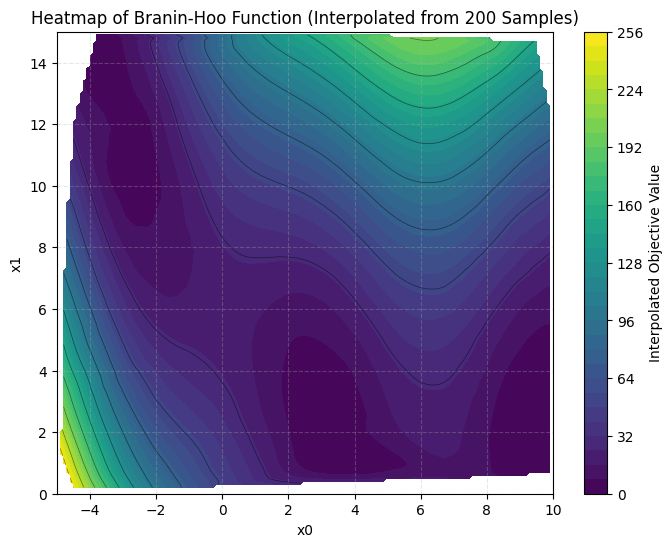

In [14]:
from scipy.interpolate import griddata

# 1. Generate Scattered Data Points
X_df = space.sample(200)
Y_flat = branin_hoo(X_df).ravel()

points = X_df[['x0', 'x1']].values
values = Y_flat

# --- 2. Define the Target Grid for Interpolation ---
n_points = 150  # Define resolution for the heatmap (150x150 grid)
x0_arr = np.linspace(space.opt_lb[0], space.opt_ub[0], n_points)
x1_arr = np.linspace(space.opt_lb[1], space.opt_ub[1], n_points)
X0_grid, X1_grid = np.meshgrid(x0_arr, x1_arr)

# --- 3. Interpolate the Scattered Data onto the Grid ---
Z_grid = griddata(points, values, (X0_grid, X1_grid), method='cubic')

# --- 4. Create the Heatmap/Contour Plot ---
plt.figure(figsize=(8, 6))
cont = plt.contourf(X0_grid, X1_grid, Z_grid, levels=40, cmap='viridis')
plt.contour(X0_grid, X1_grid, Z_grid, levels=10, colors='k', linestyles='-', linewidths=0.5, alpha=0.5)
plt.colorbar(cont, label="Interpolated Objective Value")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Heatmap of Branin-Hoo Function (Interpolated from 200 Samples)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### BO Loop

We compare three BO algorithms:
- The basic BO with LCB acquisition
- HEBO where three acquisition functions are ensembled, with input warping and power transformation
- HEBO with parallel recommendation.

We'll run BO with LCB firstly, we can see the interface is very simple

In [15]:
NUM_ITERATIONS = 64

In [17]:
bo = BO(space)
for i in range(NUM_ITERATIONS):
    rec_x = bo.suggest(n_suggestions=1)
    bo.observe(rec_x, branin_hoo(rec_x))
    if i % 4 == 0:
        print('Iter %d, best_y = %.2f' % (i, bo.y.min()))

Iter 0, best_y = 3.52
Iter 4, best_y = 0.43
Iter 8, best_y = 0.43
Iter 12, best_y = 0.43
Iter 16, best_y = 0.43
Iter 20, best_y = 0.43
Iter 24, best_y = 0.43
Iter 28, best_y = 0.43
Iter 32, best_y = 0.43
Iter 36, best_y = 0.42
Iter 40, best_y = 0.41
Iter 44, best_y = 0.41
Iter 48, best_y = 0.41
Iter 52, best_y = 0.40
Iter 56, best_y = 0.40
Iter 60, best_y = 0.40


We then run the sequential HEBO

In [18]:
hebo_seq   = HEBO(space, model_name = 'gp', rand_sample = 4)
for i in range(NUM_ITERATIONS):
    rec_x = hebo_seq.suggest(n_suggestions=1)
    hebo_seq.observe(rec_x, branin_hoo(rec_x))
    if i % 4 == 0:
        print('Iter %d, best_y = %.2f' % (i, hebo_seq.y.min()))

Iter 0, best_y = 142.80
Iter 4, best_y = 52.74
Iter 8, best_y = 9.43
Iter 12, best_y = 4.66
Iter 16, best_y = 0.60
Iter 20, best_y = 0.60
Iter 24, best_y = 0.51
Iter 28, best_y = 0.51
Iter 32, best_y = 0.44
Iter 36, best_y = 0.40
Iter 40, best_y = 0.40
Iter 44, best_y = 0.40
Iter 48, best_y = 0.40
Iter 52, best_y = 0.40
Iter 56, best_y = 0.40
Iter 60, best_y = 0.40


Finally, we run the parallel HEBO, as it would do parallel recommendation, we only run it for 16 iterations

In [19]:
hebo_batch = HEBO(space, model_name = 'gp', rand_sample = 4)
for i in range(NUM_ITERATIONS // 8):
    rec_x = hebo_batch.suggest(n_suggestions=8)
    hebo_batch.observe(rec_x, branin_hoo(rec_x))
    print('Iter %d, best_y = %.2f' % (i, hebo_batch.y.min()))

Iter 0, best_y = 13.46
Iter 1, best_y = 13.46
Iter 2, best_y = 7.96
Iter 3, best_y = 4.64
Iter 4, best_y = 1.55
Iter 5, best_y = 0.73
Iter 6, best_y = 0.44
Iter 7, best_y = 0.40


We plot the converge below, we can see it seems that the LCB converges slightly faster than HEBO, while batched HEBO used most function evaluations.

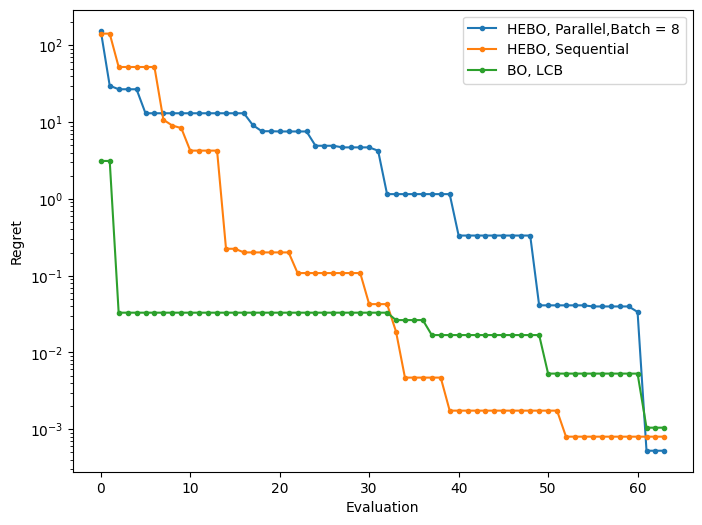

In [20]:
conv_hebo_batch = np.minimum.accumulate(hebo_batch.y)
conv_hebo_seq = np.minimum.accumulate(hebo_seq.y)
conv_bo_seq = np.minimum.accumulate(bo.y)

plt.figure(figsize = (8,6))
plt.semilogy(conv_hebo_batch - 0.3978922, '.-', label = 'HEBO, Parallel,Batch = 8')
plt.semilogy(conv_hebo_seq - 0.3978922, '.-', label = 'HEBO, Sequential')
plt.semilogy(conv_bo_seq - 0.3978922, '.-', label = 'BO, LCB')

plt.xlabel('Evaluation')
plt.ylabel('Regret')
plt.legend()

Batched HEBO used most function evaluations because it recommend eight points per iterations, we can also plot the converge against **iterations** instead of **evaluations**.

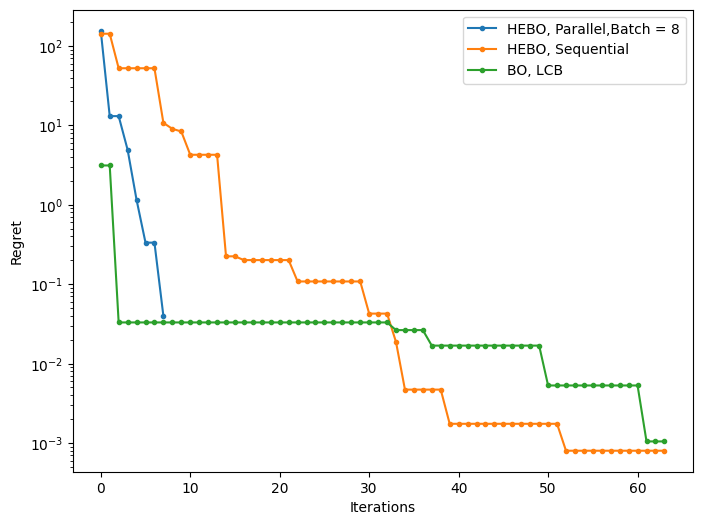

In [21]:
plt.figure(figsize = (8,6))
plt.semilogy(conv_hebo_batch[::8] - 0.3978922, '.-', label = 'HEBO, Parallel,Batch = 8')
plt.semilogy(conv_hebo_seq - 0.3978922, '.-', label = 'HEBO, Sequential')
plt.semilogy(conv_bo_seq - 0.3978922, '.-', label = 'BO, LCB')

plt.xlabel('Iterations')
plt.ylabel('Regret')
plt.legend()